## 26W-COM SCI-M148 Project 1

Name: Gene Kung

UID: 305955388

### **Submission Guidelines (Due: Jan 26, at 4PM)**

1. Please fill in your name and UID above.

2. Please submit a **PDF printout** of this Jupyter Notebook and answer the correpsonding questions on **Gradescope**. If you have any trouble accessing Gradescope, please let a TA know ASAP.  

## Setup

We'll start by importing a series of libraries we'll be using throughout the project.

In [26]:
import sys
assert sys.version_info >= (3, 5) # python>=3.5
import sklearn
#assert sklearn.__version__ >= "0.20" # sklearn >= 0.20

import numpy as np #numerical package in python
%matplotlib inline
import matplotlib.pyplot as plt #plotting package

# to make this notebook's output identical at every run
np.random.seed(42)

#matplotlib magic for inline figures
%matplotlib inline
import matplotlib # plotting library
import matplotlib.pyplot as plt

# TODO: Applying the end-end ML steps to a different dataset.

Ok now it's time to get to work! We will apply what we've learnt to another dataset (airbnb dataset). For this project we will attempt to **predict the airbnb rental price based on other features in our given dataset.**

# Visualizing Data


<!-- BEGIN QUESTION -->
### Load the data + statistics

Let's do the following set of tasks to get us warmed up:
- load the dataset
- display the first few rows of the data
- drop the following columns: name, host_id, host_name, last_review, neighbourhood
- display a summary of the statistics of the loaded data

In [27]:
from google.colab import files

files.upload() # upload nyc.png
files.upload() # upload AB_NYC_2019.csv

Output hidden; open in https://colab.research.google.com to view.

In [28]:
import pandas as pd
airbnb =  pd.read_csv('AB_NYC_2019.csv')  # we load the pandas dataframe

In [29]:
# TODO
airbnb_drop = airbnb.drop(['name', 'host_id', 'host_name', 'last_review', 'neighbourhood'], axis=1)

In [30]:
airbnb_drop.describe()

,id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [31]:
airbnb_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   neighbourhood_group             48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               38843 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 4.1+ MB


<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
### Some Basic Visualizations

Let's try another popular python graphics library: Plotly.

You can find documentation and all the examples you'll need here: [Plotly Documentation](https://plotly.com/python/basic-charts/)


Let's start out by getting a better feel for the distribution of rentals in the market.

#### Generate a pie chart showing the distribution of room type (`room_type` in the dataset) across NYC's 'Staten Island' Buroughs (fitlered by `neighbourhood_group` in the dataset)

In [32]:
import plotly.express as px
# TODO
staten_island_data = airbnb_drop[airbnb_drop['neighbourhood_group'] == 'Staten Island']
room_type_counts = staten_island_data['room_type'].value_counts().reset_index()
fig = px.pie(room_type_counts, values='count', names='room_type', title='Distribution of Room Types in Staten Island')
fig.show()

#### Plot the total number_of_reviews per room_type

We now want to see the total number of reviews left for each room type group in the form of a Bar Chart (where the X-axis is the room type group and the Y-axis is a count of review.)

**Note**: for all the listings, not just for 'Staten Island' Buroughs.

This is a two step process:
1.   You'll have to sum up the reviews per room type group **(hint! try using the groupby function)**
2.   Then use Plotly to generate the graph





In [33]:
# TODO
room = airbnb_drop.groupby('room_type')['number_of_reviews'].sum().reset_index()
room.head()
# TODO
fig = px.bar(room, x='room_type', y='number_of_reviews', title='Total Number of Reviews per Room Type')
fig.show()

<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
### Plot a map of airbnbs throughout New York.

For reference you can use the Matplotlib code above to replicate this graph here.

<Axes: xlabel='longitude', ylabel='latitude'>

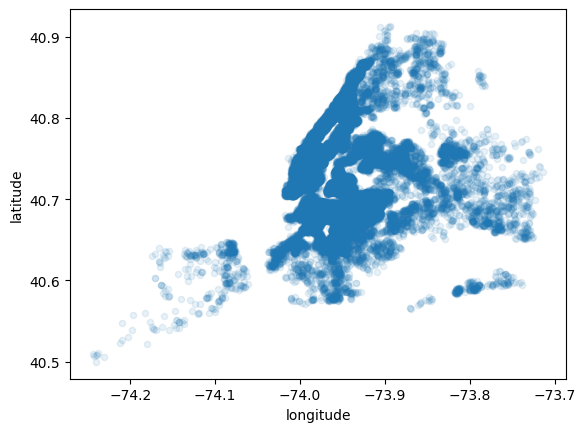

In [34]:
airbnb.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

It seems to get too crowded so let's take a subset of the data, try to filter the room with price less than 500

In [35]:
# TODO
miniairbnb = airbnb_drop[airbnb_drop['price'] < 500]

/tmp/ipython-input-3606836585.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



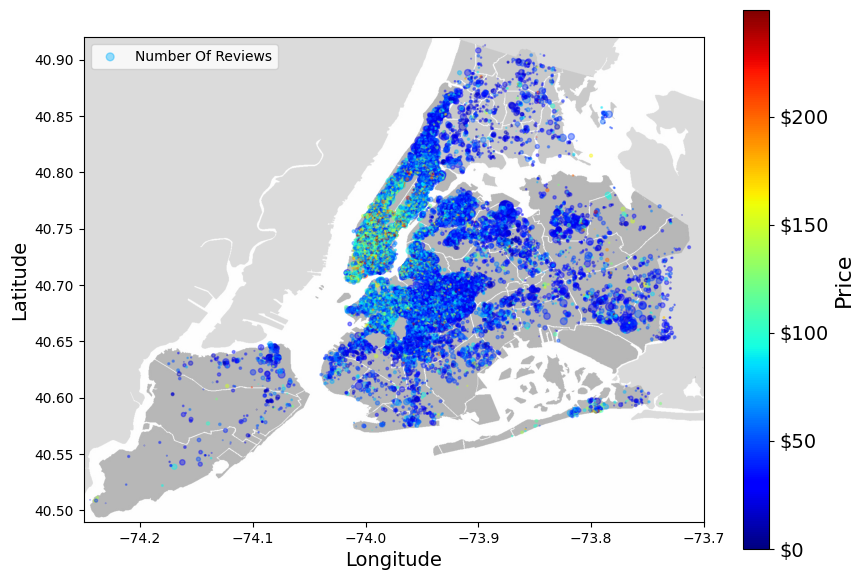

In [36]:
# A more interesting plot is to color code (heatmap) the dots
# based on price. The code below achieves this

# load an image of New York
import matplotlib.image as mpimg
nyc_img=mpimg.imread('nyc.png', -1)

# overlay the NYC map on the plotted scatter plot
# note: plt.imshow still refers to the most recent figure
# that hasn't been plotted yet.

# Using 'jet' colormap as in the tutorial
# TODO
ax = miniairbnb.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                       s=miniairbnb['number_of_reviews']/10, label="Number Of Reviews",
                       c="price", cmap=plt.get_cmap("jet"),
                       colorbar=False, alpha=0.4,
                      )
# overlay the nyc map on the plotted scatter plot
# Adjust extent for NYC coordinates
plt.imshow(nyc_img, extent=[-74.25, -73.7, 40.49, 40.92], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

# setting up heatmap colors based on price feature
prices = miniairbnb["price"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
norm = plt.Normalize(vmin=prices.min(), vmax=prices.max())
sm = plt.cm.ScalarMappable(cmap=plt.get_cmap("jet"), norm=norm)
cb = plt.colorbar(sm, ax=ax)
cb.ax.set_yticklabels(["$%d"%(round(v)) for v in tick_values], fontsize=14)
cb.set_label('Price', fontsize=16)
plt.show()

<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
Now try to recreate this plot using Plotly's Scatterplot functionality. Note that the increased interactivity of the plot allows for some very cool functionality

In [37]:
# TODO
# creates the scatter plot
fig = px.scatter(
    miniairbnb,
    x="longitude",
    y="latitude",
    color="price",
    size="number_of_reviews",
    color_continuous_scale="Jet",
    opacity=0.4,
    title="Airbnb Listings NYC (Price & Reviews)",
    width=1000,
    height=700
)

import base64
#set a local image as a background
image_filename = 'nyc.png'
plotly_logo = base64.b64encode(open(image_filename, 'rb').read())

# WRITE YOUR CODE HERE #
# create the Plotly-friendly string
encoded_image= 'data:image/png;base64,' + plotly_logo.decode('utf-8')

fig.update_layout(
  images=[dict(
    source=encoded_image,
    xref="x", yref="y",
    x=-74.25,       # Left (xmin)
    y=40.92,        # Top (ymax)
    sizex=0.55,     # Width: (-73.7) - (-74.25)
    sizey=0.43,     # Height: 40.92 - 40.49
    sizing="stretch",
    layer="below"
  )],
  yaxis=dict(scaleanchor="x", scaleratio=1),
)

"""
staten_island_data = miniairbnb[miniairbnb['neighbourhood_group'] == 'Staten Island']
max_price = staten_island_data['price'].max()
print(f"The maximum price shown in Staten Island is: {int(max_price)}")
"""

fig.show()

<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
### Use Plotly to plot the average price of room types in Brooklyn who have at least 10 Reviews.

Like with the previous example you'll have to do a little bit of data engineering before you actually generate the plot.

Generally I'd recommend the following series of steps:
1. Filter the data by neighborhood group and number of reviews to arrive at the subset of data relevant to this graph.
2. Groupby the room type
3. Take the mean of the price for each roomtype group
4. FINALLY (seriously!?!?) plot the result

In [38]:
# WRITE YOUR CODE HERE #
subgroup = airbnb_drop[
    (airbnb_drop['neighbourhood_group'] == 'Brooklyn') &
    (airbnb_drop['number_of_reviews'] >= 10)
]

avg_price = subgroup.groupby('room_type')['price'].mean().reset_index()

In [39]:
subgroup

,id,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
3,3831,Brooklyn,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
6,5121,Brooklyn,40.68688,-73.95596,Private room,60,45,49,0.40,1,0
12,5803,Brooklyn,40.66829,-73.98779,Private room,89,4,167,1.34,3,314
15,6848,Brooklyn,40.70837,-73.95352,Entire home/apt,140,2,148,1.20,1,46
16,7097,Brooklyn,40.69169,-73.97185,Entire home/apt,215,2,198,1.72,1,321
...,...,...,...,...,...,...,...,...,...,...,...
45471,34777979,Brooklyn,40.71317,-73.96066,Entire home/apt,160,1,13,7.96,1,120
45551,34819702,Brooklyn,40.64932,-73.98018,Entire home/apt,90,1,11,7.17,1,3
45581,34839277,Brooklyn,40.66261,-73.94399,Private room,55,2,11,9.17,2,44
45690,34907354,Brooklyn,40.66197,-73.95952,Private room,42,2,12,9.47,1,53


In [40]:
# WRITE YOUR CODE HERE #
import plotly.express as px

fig = px.bar(
    avg_price,
    x='room_type',
    y='price',
    title='Average Price of Room Types in Brooklyn (Min 10 Reviews)',
    labels={'price': 'Average Price ($)', 'room_type': 'Room Type'}
)
fig.show()

<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
# Prepare the Data

In [41]:
airbnb_drop.head()

,id,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Brooklyn,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Manhattan,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,Manhattan,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,3831,Brooklyn,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Manhattan,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


### Feature Engineering

Let's create a new binned feature, `price_cat` that will divide our dataset into quintiles (1-5) in terms of price level automatically

Do a value count to check the distribution of values

In [42]:
# TODO
# assign each bin a categorical value [1, 2, 3, 4, 5] in this case.
airbnb_drop["price_cat"] = pd.qcut(airbnb_drop["price"],
                                  q=5,
                                  labels=[1, 2, 3, 4, 5],
                                )

airbnb_drop["price_cat"].value_counts()

,count
price_cat,
4,10809
1,10063
2,9835
3,9804
5,8384


<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
### Data Imputation

Determine if there are any null-values and impute them with the median value.


In [43]:
airbnb_drop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48895 non-null  int64   
 1   neighbourhood_group             48895 non-null  object  
 2   latitude                        48895 non-null  float64 
 3   longitude                       48895 non-null  float64 
 4   room_type                       48895 non-null  object  
 5   price                           48895 non-null  int64   
 6   minimum_nights                  48895 non-null  int64   
 7   number_of_reviews               48895 non-null  int64   
 8   reviews_per_month               38843 non-null  float64 
 9   calculated_host_listings_count  48895 non-null  int64   
 10  availability_365                48895 non-null  int64   
 11  price_cat                       48895 non-null  category
dtypes: category(1), fl

In [44]:
# WRITE YOUR CODE HERE #
airbnb_drop.info()
median = airbnb_drop["reviews_per_month"].median()
airbnb_drop["reviews_per_month"] = airbnb_drop["reviews_per_month"].fillna(median)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48895 non-null  int64   
 1   neighbourhood_group             48895 non-null  object  
 2   latitude                        48895 non-null  float64 
 3   longitude                       48895 non-null  float64 
 4   room_type                       48895 non-null  object  
 5   price                           48895 non-null  int64   
 6   minimum_nights                  48895 non-null  int64   
 7   number_of_reviews               48895 non-null  int64   
 8   reviews_per_month               38843 non-null  float64 
 9   calculated_host_listings_count  48895 non-null  int64   
 10  availability_365                48895 non-null  int64   
 11  price_cat                       48895 non-null  category
dtypes: category(1), fl

<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
### Numeric Conversions

Finally, review what features in your dataset are non-numeric and convert them.

In [45]:
# WRITE YOUR CODE HERE #
airbnb_drop.info()

from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

airbnb_drop["neighbourhood_group"] = labelencoder.fit_transform(airbnb_drop["neighbourhood_group"])
airbnb_drop["room_type"] = labelencoder.fit_transform(airbnb_drop["room_type"])

airbnb_drop["price_cat"] = airbnb_drop["price_cat"].astype(int)

airbnb_drop.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48895 non-null  int64   
 1   neighbourhood_group             48895 non-null  object  
 2   latitude                        48895 non-null  float64 
 3   longitude                       48895 non-null  float64 
 4   room_type                       48895 non-null  object  
 5   price                           48895 non-null  int64   
 6   minimum_nights                  48895 non-null  int64   
 7   number_of_reviews               48895 non-null  int64   
 8   reviews_per_month               48895 non-null  float64 
 9   calculated_host_listings_count  48895 non-null  int64   
 10  availability_365                48895 non-null  int64   
 11  price_cat                       48895 non-null  category
dtypes: category(1), fl

,id,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,price_cat
0,2539,1,40.64749,-73.97237,1,149,1,9,0.21,6,365,4
1,2595,2,40.75362,-73.98377,0,225,1,45,0.38,2,355,5
2,3647,2,40.80902,-73.94190,1,150,3,0,0.72,1,365,4
3,3831,1,40.68514,-73.95976,0,89,1,270,4.64,1,194,2
4,5022,2,40.79851,-73.94399,0,80,10,9,0.10,1,0,2


<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
# Prepare Data for Machine Learning

Using our `StratifiedShuffleSplit` function example from above, let's split our data into a 80/20 Training/Testing split using `price_cat` to partition the dataset

In [46]:
from sklearn.model_selection import StratifiedShuffleSplit
# let's first start by creating our train and test sets

# WRITE YOUR CODE HERE  (Use random state 42) #
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_set, test_set = None, None

for train_index, test_index in split.split(airbnb_drop, airbnb_drop["price_cat"]):
  train_set = airbnb_drop.loc[train_index]
  test_set = airbnb_drop.loc[test_index]

In [47]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9779 entries, 34229 to 20813
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9779 non-null   int64  
 1   neighbourhood_group             9779 non-null   int64  
 2   latitude                        9779 non-null   float64
 3   longitude                       9779 non-null   float64
 4   room_type                       9779 non-null   int64  
 5   price                           9779 non-null   int64  
 6   minimum_nights                  9779 non-null   int64  
 7   number_of_reviews               9779 non-null   int64  
 8   reviews_per_month               9779 non-null   float64
 9   calculated_host_listings_count  9779 non-null   int64  
 10  availability_365                9779 non-null   int64  
 11  price_cat                       9779 non-null   int64  
dtypes: float64(3), int64(9)
memory usa

Finally, remove your labels `price` and `price_cat` from your testing and training cohorts, and create separate label features using `price`.

In [48]:
# WRITE YOUR CODE HERE #
training = train_set.drop(["price", "price_cat"], axis=1)
training_labels = train_set["price"].copy()

testing = test_set.drop(["price", "price_cat"], axis=1)
testing_labels = test_set["price"].copy()

In [49]:
training.head()

,id,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
40334,31283904,2,40.72846,-73.98457,0,1,10,1.67,1,332
12438,9578325,1,40.67924,-73.98718,0,1,120,2.73,2,275
35502,28181243,1,40.66891,-73.93495,0,3,2,0.24,1,362
6553,4750578,1,40.68589,-73.95759,0,1,0,0.72,1,0
19465,15529937,1,40.60983,-73.95887,1,2,26,0.98,3,101


<!-- END QUESTION -->
<!-- BEGIN QUESTION -->
# Fit a linear regression model

The task is to predict the price, you could refer to the housing example on how to train and evaluate your model using **MSE**.
Provide both **test and train set MSE values**.

In [50]:
# WRITE YOUR CODE HERE #
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lin_reg = LinearRegression()
lin_reg.fit(training, training_labels)

training_preds = lin_reg.predict(training)
training_mse = mean_squared_error(training_labels, training_preds)
print(f"Training MSE: {training_mse}")

testing_preds = lin_reg.predict(testing)
testing_mse = mean_squared_error(testing_labels, testing_preds)
print(f"Testing MSE:  {testing_mse}")

Training MSE: 56062.46938087336
Testing MSE:  38352.06181543438


## PDF Export:
Once everything is done, export this file to PDF and submit it through Gradescope.

Run the following code on Colab can automatically export a PDF. It might take a few minutes.

In [51]:
def colab2pdf():
  ENABLE = True  # @param {type:"boolean"}
  if not ENABLE:
    return

  import os, sys, json, datetime, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings, subprocess
  !apt-get -qq install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2
  BASE_DIR = pathlib.Path.cwd()     # where your csv lives
  PDF_DIR  = BASE_DIR / "pdfs"
  PDF_DIR.mkdir(parents=True, exist_ok=True)

  # Install kaleido into the *current* Python environment (reliable for nbconvert)
  subprocess.run([sys.executable, "-m", "pip", "install", "-U", "plotly>=6.1.0", "kaleido>=1.0.0"], check=True)
  subprocess.run(["bash", "-lc", "plotly_get_chrome -y"], check=False)
  # Get notebook name
  try:
    sess = requests.get(
      f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions"
    ).json()
    raw_name = sess[0]["name"]
  except Exception:
    raw_name = "notebook.ipynb"

  NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(raw_name)))
  ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
  stem = NAME.stem or "notebook"

  # Read current notebook content from Colab
  ipynb = google.colab._message.blocking_request("get_ipynb", timeout_sec=600)["ipynb"]
  nb = nbformat.reads(json.dumps(ipynb), as_version=4)

  # Remove excluded cells
  nb.cells = [c for c in nb.cells if "--Colab2PDF" not in (getattr(c, "source", "") or "")]

  # Inject: fix working dir + make Plotly export static images
  injected = nbformat.v4.new_code_cell(
f"""# --- Colab2PDF injected cell ---
import os
os.chdir(r"{str(BASE_DIR)}")

import plotly.io as pio
pio.renderers.default = "png"  # or "svg"
"""
  )
  nb.cells = [injected] + nb.cells

  # Ensure kernelspec metadata exists
  ks = dict(nb.metadata.get("kernelspec", {}) or {})
  ks.setdefault("name", "python3")
  ks.setdefault("display_name", "Python 3")
  ks.setdefault("language", "python")
  nb.metadata["kernelspec"] = ks

  warnings.filterwarnings("ignore", category=nbformat.validator.MissingIDFieldWarning)

  export_nb = BASE_DIR / f"__colab2pdf_{ts}_{stem}.ipynb"
  exec_nb   = BASE_DIR / f"__colab2pdf_{ts}_{stem}.executed.ipynb"
  cfg_yml   = BASE_DIR / f"__colab2pdf_{ts}_{stem}.config.yml"
  out_pdf_name = f"{stem}.pdf"

  with export_nb.open("w", encoding="utf-8") as f:
    nbformat.write(nb, f)

  # Install Quarto + TinyTeX if missing
  if not pathlib.Path("/usr/local/bin/quarto").exists():
    subprocess.run(["bash", "-lc", "wget -q https://quarto.org/download/latest/quarto-linux-amd64.deb -O /tmp/quarto.deb"], check=True)
    subprocess.run(["bash", "-lc", "dpkg -i /tmp/quarto.deb >/dev/null"], check=True)
    subprocess.run(["bash", "-lc", "quarto install tinytex --update-path --quiet"], check=True)

  # Quarto config for better code wrapping
  with cfg_yml.open("w", encoding="utf-8") as f:
    yaml.dump(
      {
        "include-in-header": [
          {"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}
        ],
        "include-before-body": [
          {"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}
        ],
      },
      f
    )

  # Execute notebook in BASE_DIR so relative paths work
  exec_cmd = [
    "jupyter", "nbconvert",
    "--to", "notebook",
    "--execute",
    "--ExecutePreprocessor.timeout=1800",
    "--ExecutePreprocessor.kernel_name=python3",
    "--output", exec_nb.name,
    str(export_nb),
  ]
  proc_exec = subprocess.run(exec_cmd, cwd=str(BASE_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
  if proc_exec.returncode != 0 or not exec_nb.exists():
    print("=== nbconvert execute output (last 4000 chars) ===")
    print(proc_exec.stdout[-4000:])
    raise RuntimeError("Notebook execution failed. See logs above.")

  # Render executed notebook to PDF (no execution)
  render_cmd = [
    "quarto", "render", str(exec_nb),
    "--metadata-file", str(cfg_yml),
    "--to", "pdf",
    "--output-dir", str(PDF_DIR),
    "--output", out_pdf_name,
    "-M", "latex-auto-install",
    "-M", "margin-top=1in",
    "-M", "margin-bottom=1in",
    "-M", "margin-left=1in",
    "-M", "margin-right=1in",
  ]
  proc_q = subprocess.run(render_cmd, cwd=str(BASE_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

  pdf_path = PDF_DIR / out_pdf_name
  if not pdf_path.exists():
    print("=== Quarto output (last 4000 chars) ===")
    print(proc_q.stdout[-4000:])
    raise FileNotFoundError(f"No PDF produced at: {pdf_path}")

  import google.colab.files
  google.colab.files.download(str(pdf_path))

  # Optional cleanup:
  # export_nb.unlink(missing_ok=True)
  # exec_nb.unlink(missing_ok=True)
  # cfg_yml.unlink(missing_ok=True)


# run it
colab2pdf()


Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../0-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../1-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../2-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../3-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected package at-spi2-core.
Preparing to unpack .../4-at-spi2-core_2.44.0-3_amd64.deb ...
Unpacking at-spi2-core (2.44.0-3) ...
Selecting previously unselected package libatk1.0-data.
Preparing to u

RuntimeError: Notebook execution failed. See logs above.